# Ligand-Receptor Interaction Correlation (LRIC)


In this tutorial, we demonstrate how cross pair-correlation function **(cross-PCF)** and Ligand–Receptor Interaction Correlation **(LRIC)** can be used to infer cell–cell communication spatial scales.
<br>

**Cross-PCF** measures whether two cell types occur near one another more or less frequently than expected at given distances.
<br>

**LRIC** extends this idea by incorporating ligand and receptor expression. Rather than counting every neighbouring cell pair equally, it weights **sender cells by ligand expression** and **receiver cells by receptor expression**.
<br>

<img src="LRIC_summary.png" width=1000 />

#### Interpreting cross-PCF and LRIC results

Both methods return a distance-dependent statistic, `(g(r))`, calculated for spatial distance bins centred around a given distance (r).
<br>

g(r) > 1 indicates enrichment at distance r. <br>
g(r) ≈ 1 indicates no enrichment beyond the null expectation. <br>
g(r) < 1 indicates depletion or spatial avoidance.

## Environment Setup

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

import liana as li

import warnings
warnings.filterwarnings("ignore")

## Load and Normalize Data

To demonstrate the LRIC in practice, we will apply it to a spatial transcriptomics dataset from [A molecularly defined and spatially resolved cell atlas of the whole mouse brain(Nature, 2023)](https://www.nature.com/articles/s41586-023-06808-9); [WB_MERFISH_animal2_coronal](https://cellxgene.cziscience.com/collections/0cca8620-8dee-45d0-aef5-23f032a5cf09).

The dataset was generated using **MERFISH** technique, which enables highly multiplexed single-molecule RNA imaging with subcellular spatial resolution. This dataset profiles the expression of more than **1,000** genes across roughly **10 million cells** in the adult **mouse brain**.

In [2]:
file_path  = "data/MERFISH_mouse_brain/WB_MERFISH_animal2_coronal.h5ad"
backup_url = "https://datasets.cellxgene.cziscience.com/93c3bb97-ea05-4ee0-a760-a1508cd04612.h5ad"

adata = sc.read(file_path, backup_url=backup_url)

# Subset to one brain section
adata = adata[adata.obs["brain_section_label"] == "C57BL6J-2.039"]
# The dataset indexes vars by Ensembl ID; switch to gene symbols for LR lookup
adata.var_names = adata.var["gene_name"]

# Basic QC
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)

# Normalise (keep raw counts in a layer); LRIC will use normalised log1p values
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Spatial coordinates are in µm (MERFISH physical units)
print(adata)

AnnData object with n_obs × n_vars = 51539 × 1120
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'log1p'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'
    layers: 'counts'


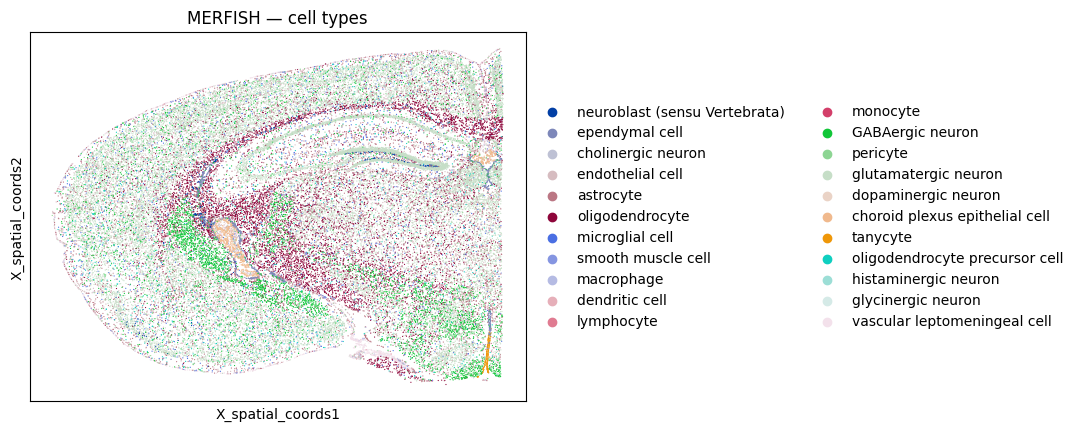

In [3]:
sc.pl.embedding(
    adata, basis="X_spatial_coords",
    color="cell_type", s=3, title="MERFISH — cell types"
)

In [4]:
## Set variables 
cell_type_key = "cell_type"
spatial_key="X_spatial_coords"
region_key = "major_brain_region"

## Ligand–Receptor Database (mouse)

In [5]:
resource = li.rs.select_resource('mouseconsensus')
print(f"{len(resource)} LR pairs in resource")
resource.head(5)

3989 LR pairs in resource


,ligand,receptor
31367,Dll1,Notch1
31368,Dll1,Notch2
31369,Dll1,Notch4
31370,Dll1,Notch3
31371,Nrg2,Erbb2_Erbb3


### Choose the right parameters
All distance parameters are in the same units as the spatial coordinates **µm** for this MERFISH dataset. <br>
**radius_step** = step between bin inner edges (e.g. 20-25 µm, the typical upper bound of the diameter of generic cells; though this might vary a lot depending on the tissue and cell types!). <br>
**annulus_steps** = width of each annulus ring, counted in `radius_step`s (so the ring width is `annulus_steps * radius_step`). <br>
The default `annulus_steps = 1` gives non-overlapping bins that tile the full range without gaps. Setting `annulus_steps > 1` makes consecutive annuli overlap — a moving window over the same tiles — which smooths `g(r)` at the cost of correlating neighbouring bins. <br>
**max_radius** = inner edge of the last (widest) bin; the outer edge extends to `max_radius + annulus_steps * radius_step`. <br>

In [6]:
radius_step = 20

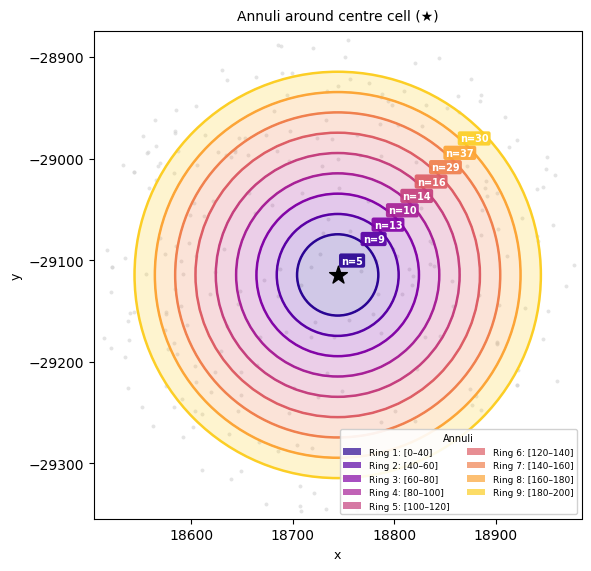

In [7]:
li.pl.annulus_plot(
    adata,
    spatial_key="X_spatial_coords",
    radius_step=radius_step,
    n_rings=9,
    seed=5,
    figure_size= (6, 6))

Note that, by default (`extend_first_annulus=True`), the innermost `[0, radius_step)` contact band is merged **into the first annulus**, which therefore spans `[0, (1 + annulus_steps) * radius_step)` and starts at radius 0. Distances are measured from each **focal cell's centroid**, so cell centroids cannot lie closer than ~one cell diameter; the innermost band is otherwise a thin, near-empty, high-variance bin. Merging it folds genuine cell–cell contact pairs into the first bin instead of discarding them. Set `extend_first_annulus=False` to keep the first ring at `[radius_step, (1 + annulus_steps) * radius_step)`.

## Ranking interactions using AUC–log2 score


`g(r)` is a curve per interaction. To compare many interactions, we apply the **AUC-log2 score**: the mean area under `log2 g(r)`.

- **`log2`** puts enrichment and depletion on one symmetric axis: `0` = null,
  `+1` = 2× enriched, `−1` = 2× depleted.
- **Integrate over radius.** The score is the area under `log2 g(r)`,

$$\text{score} = \frac{1}{\Delta r}\int \log_2 g(r)\,dr$$

Integrating (rather than taking the peak) makes the score reflect the *whole*
curve: a pair that is consistently enriched across radii accumulates a large
area, while a single noisy bin contributes only a thin sliver. Dividing by the
radial span `Δr` turns the area into a **mean log2 fold-change**, comparable
across samples and radius grids. By default the integral is taken over a
**short-range window** (`max_dist`).

`li.ut.get_lric_auc` returns one row per interaction with the same id columns as the
result it summarises (`source`/`target`/`ligand_complex`/`receptor_complex`/`interaction`)
plus `score`, sorted most-enriched first — so it drops straight into `li.pl.dotplot`.
By default `g(r)` is floored at `0.05` before the `log2`, so depleted/empty
bins stay finite and count as strong depletion; pass `transform_fn=np.log2`
to instead drop non-finite bins.

**Read it as:** `> 0` co-enriched, `< 0` depleted, `≈ 0` random. The magnitude
is a fold-change (`2**score`, so `1` ≈ 2×).


## CrossPCF

Cross-PCF answers a **purely spatial** question:

> Are cells of type B more (or less) frequent around cells of type A at distance r than expected if cell-type labels were randomly shuffled across the same observed cell locations?

It treats all cells **equally**. Gene expression is not considered. We use it to characterise the raw spatial architecture of the tissue before asking about LR interactions.

In [8]:
li.mt.cross_pcf(
    adata,
    groupby=cell_type_key,
    spatial_key=spatial_key,
    max_radius=250,
    radius_step=radius_step,
    min_cells= None,
    key_added="cross_pcf", #results will be saved under this label in adata.uns
    verbose=True,
)

`min_cells=None`: dropping cell types with <= 1.0% of 51539 cells (min_cells=516).
Using `.X`!
The following cell identities were excluded: neuroblast (sensu Vertebrata), cholinergic neuron, smooth muscle cell, macrophage, dendritic cell, lymphocyte, monocyte, dopaminergic neuron, tanycyte, histaminergic neuron, glycinergic neuron
Computing cross-PCF for 11 cell types (55 pairs).


In [9]:
## Explore the output: one row per cell-type pair x radius bin
adata.uns["cross_pcf"].head()


,source,target,interaction,radius,g
0,GABAergic neuron,astrocyte,GABAergic neuron^astrocyte,0.0,0.861141
1,GABAergic neuron,astrocyte,GABAergic neuron^astrocyte,40.0,0.905863
2,GABAergic neuron,astrocyte,GABAergic neuron^astrocyte,60.0,0.934052
3,GABAergic neuron,astrocyte,GABAergic neuron^astrocyte,80.0,0.979085
4,GABAergic neuron,astrocyte,GABAergic neuron^astrocyte,100.0,0.994321


### Aggregation: cells cluster together at a short distance

**Choroid plexus epithelial cells** and **ependymal cells** shows strong spatial enrichment, consistent with their anatomical continuity along the ventricular surface. Choroid plexus epithelium is a specialised ventricular epithelium that meets the ependymal lining at choroid plexus attachment and transition zones.

In [10]:
# rank short-range interactions (max_dist=50 µm) by area under log2 g(r) curve
cross_pcf_res = li.ut.get_lric_auc(adata, "cross_pcf", max_dist=50, min_bins=2)
print(cross_pcf_res.head(3).to_string(index=False))


                        source                       target                                                 interaction    score  peak_radius
choroid plexus epithelial cell               ependymal cell               choroid plexus epithelial cell^ependymal cell 3.752287         40.0
choroid plexus epithelial cell vascular leptomeningeal cell choroid plexus epithelial cell^vascular leptomeningeal cell 2.576310         40.0
choroid plexus epithelial cell                     pericyte                     choroid plexus epithelial cell^pericyte 1.306699         40.0


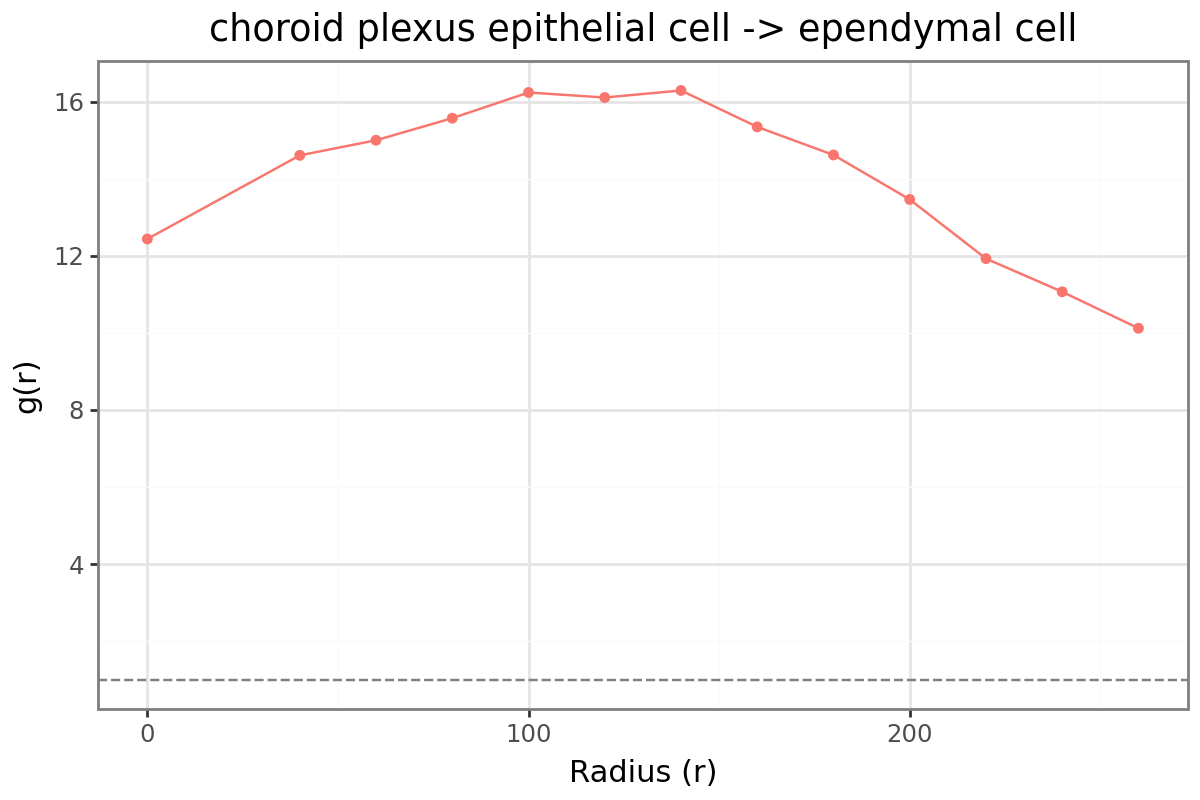

In [11]:
li.pl.lric_lineplot(adata, "cross_pcf",
                    source="choroid plexus epithelial cell",
                    target="ependymal cell")


### Exclusion: cells occupy distinct anatomical compartments

**Choroid plexus epithelial cells** are confined to the choroid plexus at the ventricular interface, whereas **glutamatergic neurons** are distributed throughout the surrounding brain parenchyma. Their strong depletion, with `g(r)<1`, indicates fewer cross-type neighbours than expected and primarily reflects spatial compartmentalisation rather than direct cellular repulsion.

In [12]:
print(cross_pcf_res.tail(3).to_string(index=False))


                        source                         target                                                   interaction     score  peak_radius
choroid plexus epithelial cell           glutamatergic neuron           choroid plexus epithelial cell^glutamatergic neuron -3.116759          0.0
choroid plexus epithelial cell                oligodendrocyte                choroid plexus epithelial cell^oligodendrocyte -3.207982          0.0
choroid plexus epithelial cell oligodendrocyte precursor cell choroid plexus epithelial cell^oligodendrocyte precursor cell -3.836286          0.0


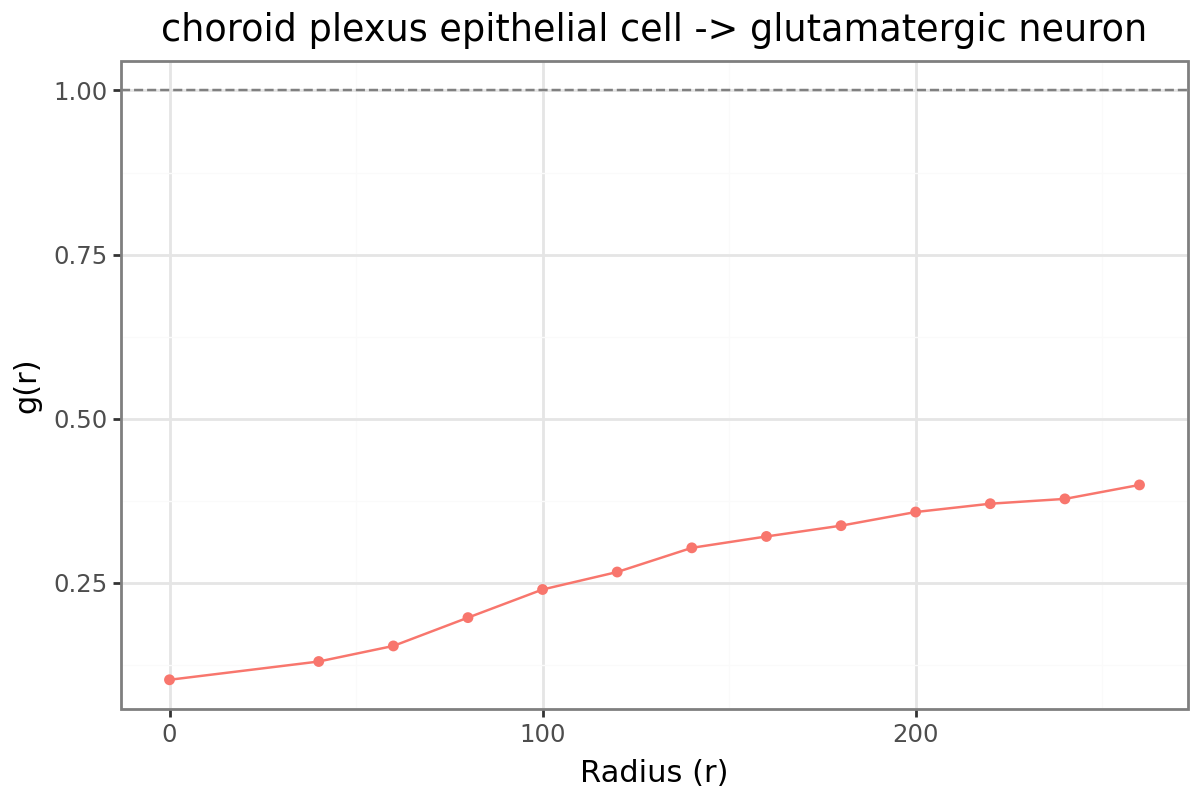

In [13]:
li.pl.lric_lineplot(adata, "cross_pcf",
                    source="choroid plexus epithelial cell",
                    target="glutamatergic neuron")


## Ligand–Receptor Global Co-expression using LRIC

The agnostic mode of LRIC answers questions like:

> Across all cells in the tissue, is the ligand signal spatially enriched around receptor-expressing receiver cells at distance r more than expected by chance?

In [14]:
li.mt.lric(
    adata,
    resource=resource,
    spatial_key=spatial_key,
    max_radius=250,
    radius_step=radius_step,
    expr_prop  = 0.05,  # NaN-mask ligand/receptor pairs expressed in <2% of cells
    use_raw=False,
    key_added="lric_ag",  #results will be saved under this label in adata.uns
    verbose=True,
)

Using `.X`!


Using provided `resource`.


0.85 of entities in the resource are missing from the data.
Running cell-type-agnostic LRIC.


In [15]:
## Explore the output: one row per ligand-receptor pair x radius bin
adata.uns["lric_ag"].head()


,ligand_complex,receptor_complex,interaction,radius,g
0,Adam12,Itga9,Adam12^Itga9,0.0,1.258836
1,Adam12,Itga9,Adam12^Itga9,40.0,1.096720
2,Adam12,Itga9,Adam12^Itga9,60.0,1.091336
3,Adam12,Itga9,Adam12^Itga9,80.0,1.068464
4,Adam12,Itga9,Adam12^Itga9,100.0,1.064509


### Strong short-range ligand-receptor spatial co-enrichment

In [16]:
# short-range
lric_ag_res = li.ut.get_lric_auc(adata, "lric_ag", max_dist=50, min_bins=2)
print(lric_ag_res.head(3).to_string(index=False))

ligand_complex receptor_complex  interaction    score  peak_radius
          Pdyn            Oprd1   Pdyn^Oprd1 0.762050          0.0
          Penk            Oprd1   Penk^Oprd1 0.621410          0.0
       Col18a1             Gpc4 Col18a1^Gpc4 0.458144          0.0


**Pdyn $\rightarrow$ Oprd1** shows short-range spatial co-enrichment, with $g(r)$ reaching approximately **1.8 at the shortest distance**. This means that **Pdyn- and Oprd1-expressing cells are found near each other more often than expected based on their overall expression patterns across the tissue**. The enrichment becomes weaker with distance but remains above the baseline, suggesting that the association is strongest locally and still present over a broader spatial range.

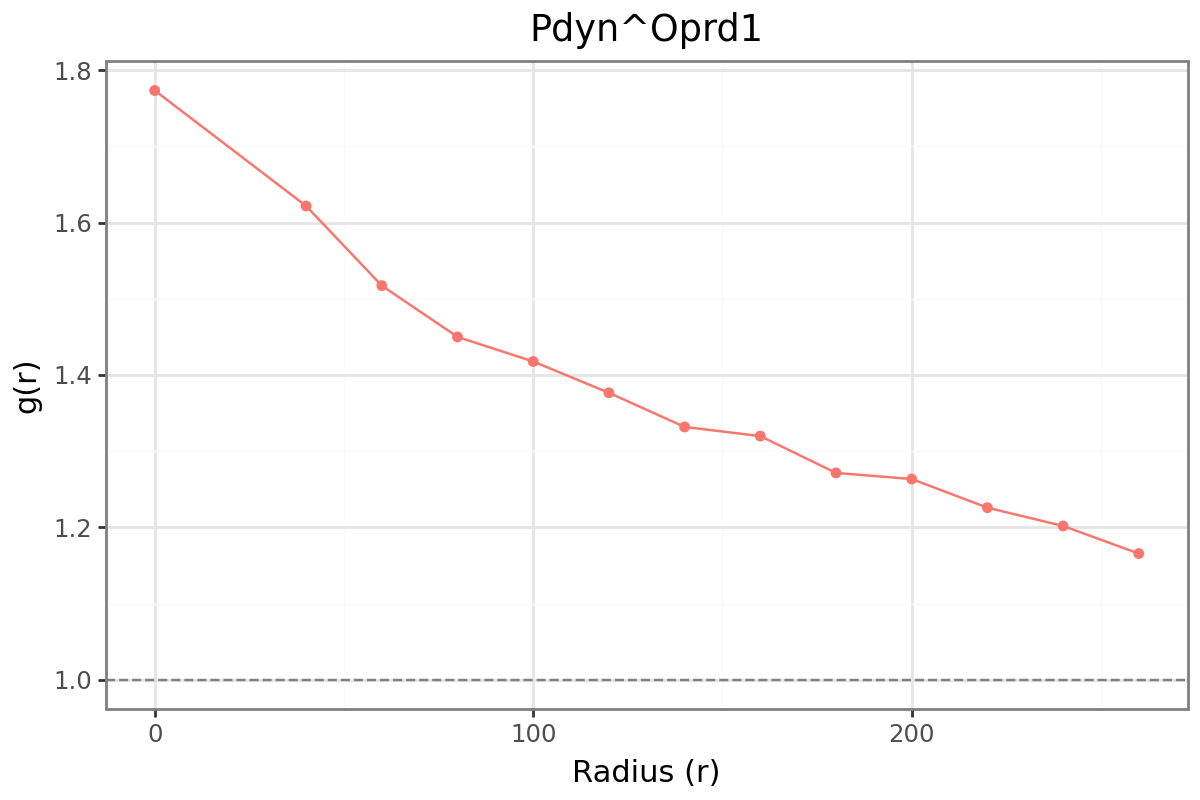

In [17]:
li.pl.lric_lineplot(adata, "lric_ag", interaction="Pdyn^Oprd1")

### Strong short-range spatial depletion

In [18]:
print(lric_ag_res.tail(3).to_string(index=False))

ligand_complex receptor_complex interaction     score  peak_radius
           Dcn            Erbb4   Dcn^Erbb4 -0.285135          0.0
         Vegfc            Vipr2 Vegfc^Vipr2 -0.341919          0.0
          Kitl              Kit    Kitl^Kit -0.355022          0.0


**Dcn $\rightarrow$ Erbb4** shows short-range spatial depletion, with $g(r)$ reaching approximately **0.77 at the shortest distance** and remaining below **1 within $40\,\mu\mathrm{m}$**. This means that **Dcn- and Erbb4-expressing cells are found near each other less often than expected**.

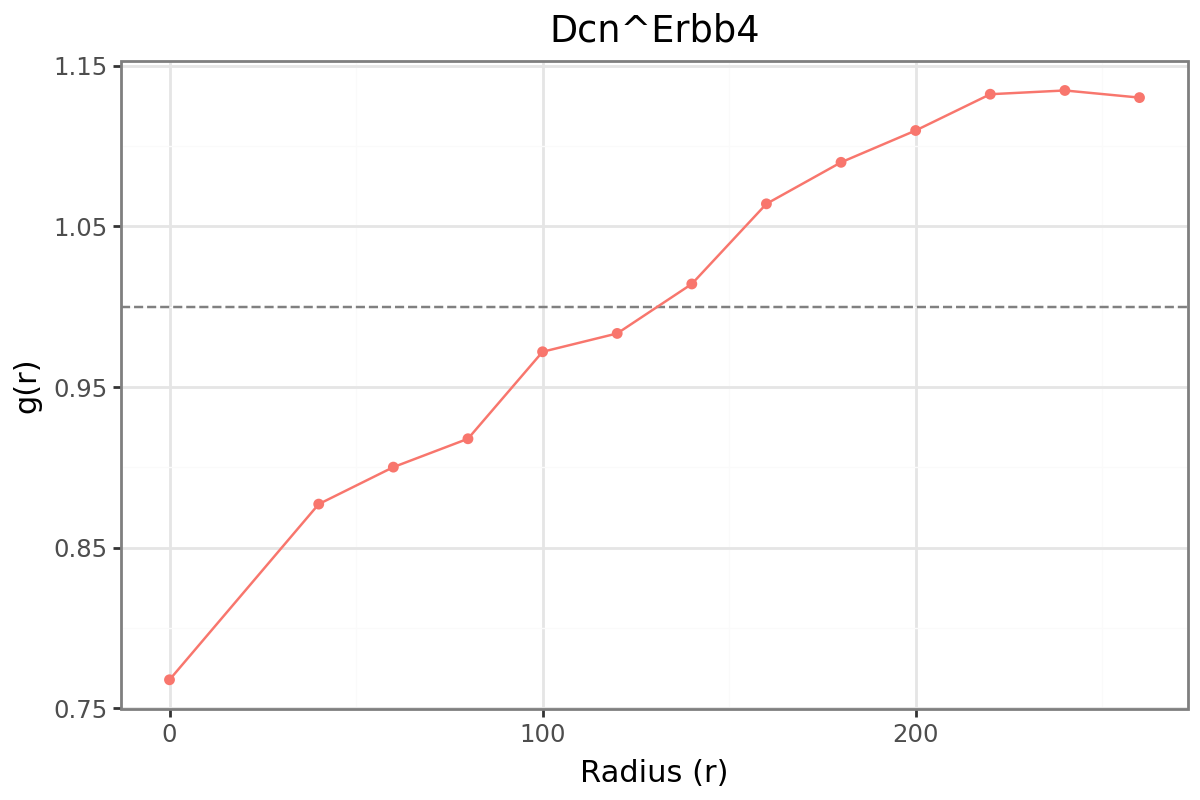

In [19]:
li.pl.lric_lineplot(adata, "lric_ag", interaction="Dcn^Erbb4")

## LRIC Cell-Type Informed for Directed Interactions

The **cell-type-informed** mode splits cells into sender and receiver populations by cell-type annotation and computes g(r) for every directed **(sender → receiver)** pair, weighted by the LR expression.

This answers a more specific question:

> For the specific interaction **sender cell type X expressing ligand L** → **receiver cell type Y expressing receptor R**, is the LR-weighted spatial co-enrichment at distance r higher than expected?

**Key advantage over cross-PCF**: the expression weighting means g(r) > 1 can only be driven by cells that express the relevant ligand/receptor.

In [20]:
li.mt.lric(
    adata,
    resource=resource,
    groupby=cell_type_key,
    spatial_key=spatial_key,
    max_radius=250,
    radius_step=radius_step,
    expr_prop=0.2,  # NaN-mask sender/receiver-celltype pairs expressed in <2% of that celltype
    use_raw=False,
    key_added="lric_ct", #results will be saved under this label in adata.uns
    verbose=True,
)

`min_cells=None`: dropping cell types with <= 1.0% of 51539 cells (min_cells=516).
Using `.X`!
The following cell identities were excluded: neuroblast (sensu Vertebrata), cholinergic neuron, smooth muscle cell, macrophage, dendritic cell, lymphocyte, monocyte, dopaminergic neuron, tanycyte, histaminergic neuron, glycinergic neuron


Using provided `resource`.


0.85 of entities in the resource are missing from the data.
Running LRIC (conditional within-type null) for 11 cell types (110 directed pairs).
LRIC: 100%|██████████| 110/110 [00:03<00:00, 28.70it/s]


In [21]:
# short-range interactions (max_dist=50 µm) by area under log2 g(r) curve
lric_ct_res = li.ut.get_lric_auc(adata, "lric_ct", max_dist=50, min_bins=2)
print(lric_ct_res.head(3).to_string(index=False))


                        source                         target ligand_complex receptor_complex  interaction    score  peak_radius
  vascular leptomeningeal cell choroid plexus epithelial cell        Col18a1             Gpc4 Col18a1^Gpc4 3.896360         40.0
choroid plexus epithelial cell                 ependymal cell        Sostdc1             Lrp4 Sostdc1^Lrp4 3.759548         40.0
choroid plexus epithelial cell                 ependymal cell        Col18a1             Gpc4 Col18a1^Gpc4 3.735166         40.0


The AUC ranking uses liana's own column names, so it feeds straight into `li.pl.dotplot`. Rather than mapping the same score twice, colour shows the **magnitude** (AUC-log2) while dot size shows `peak_radius` — the radius at which each interaction deviates most from the null. With `inverse_size=True`, bigger dots mean tighter, shorter-range coupling.

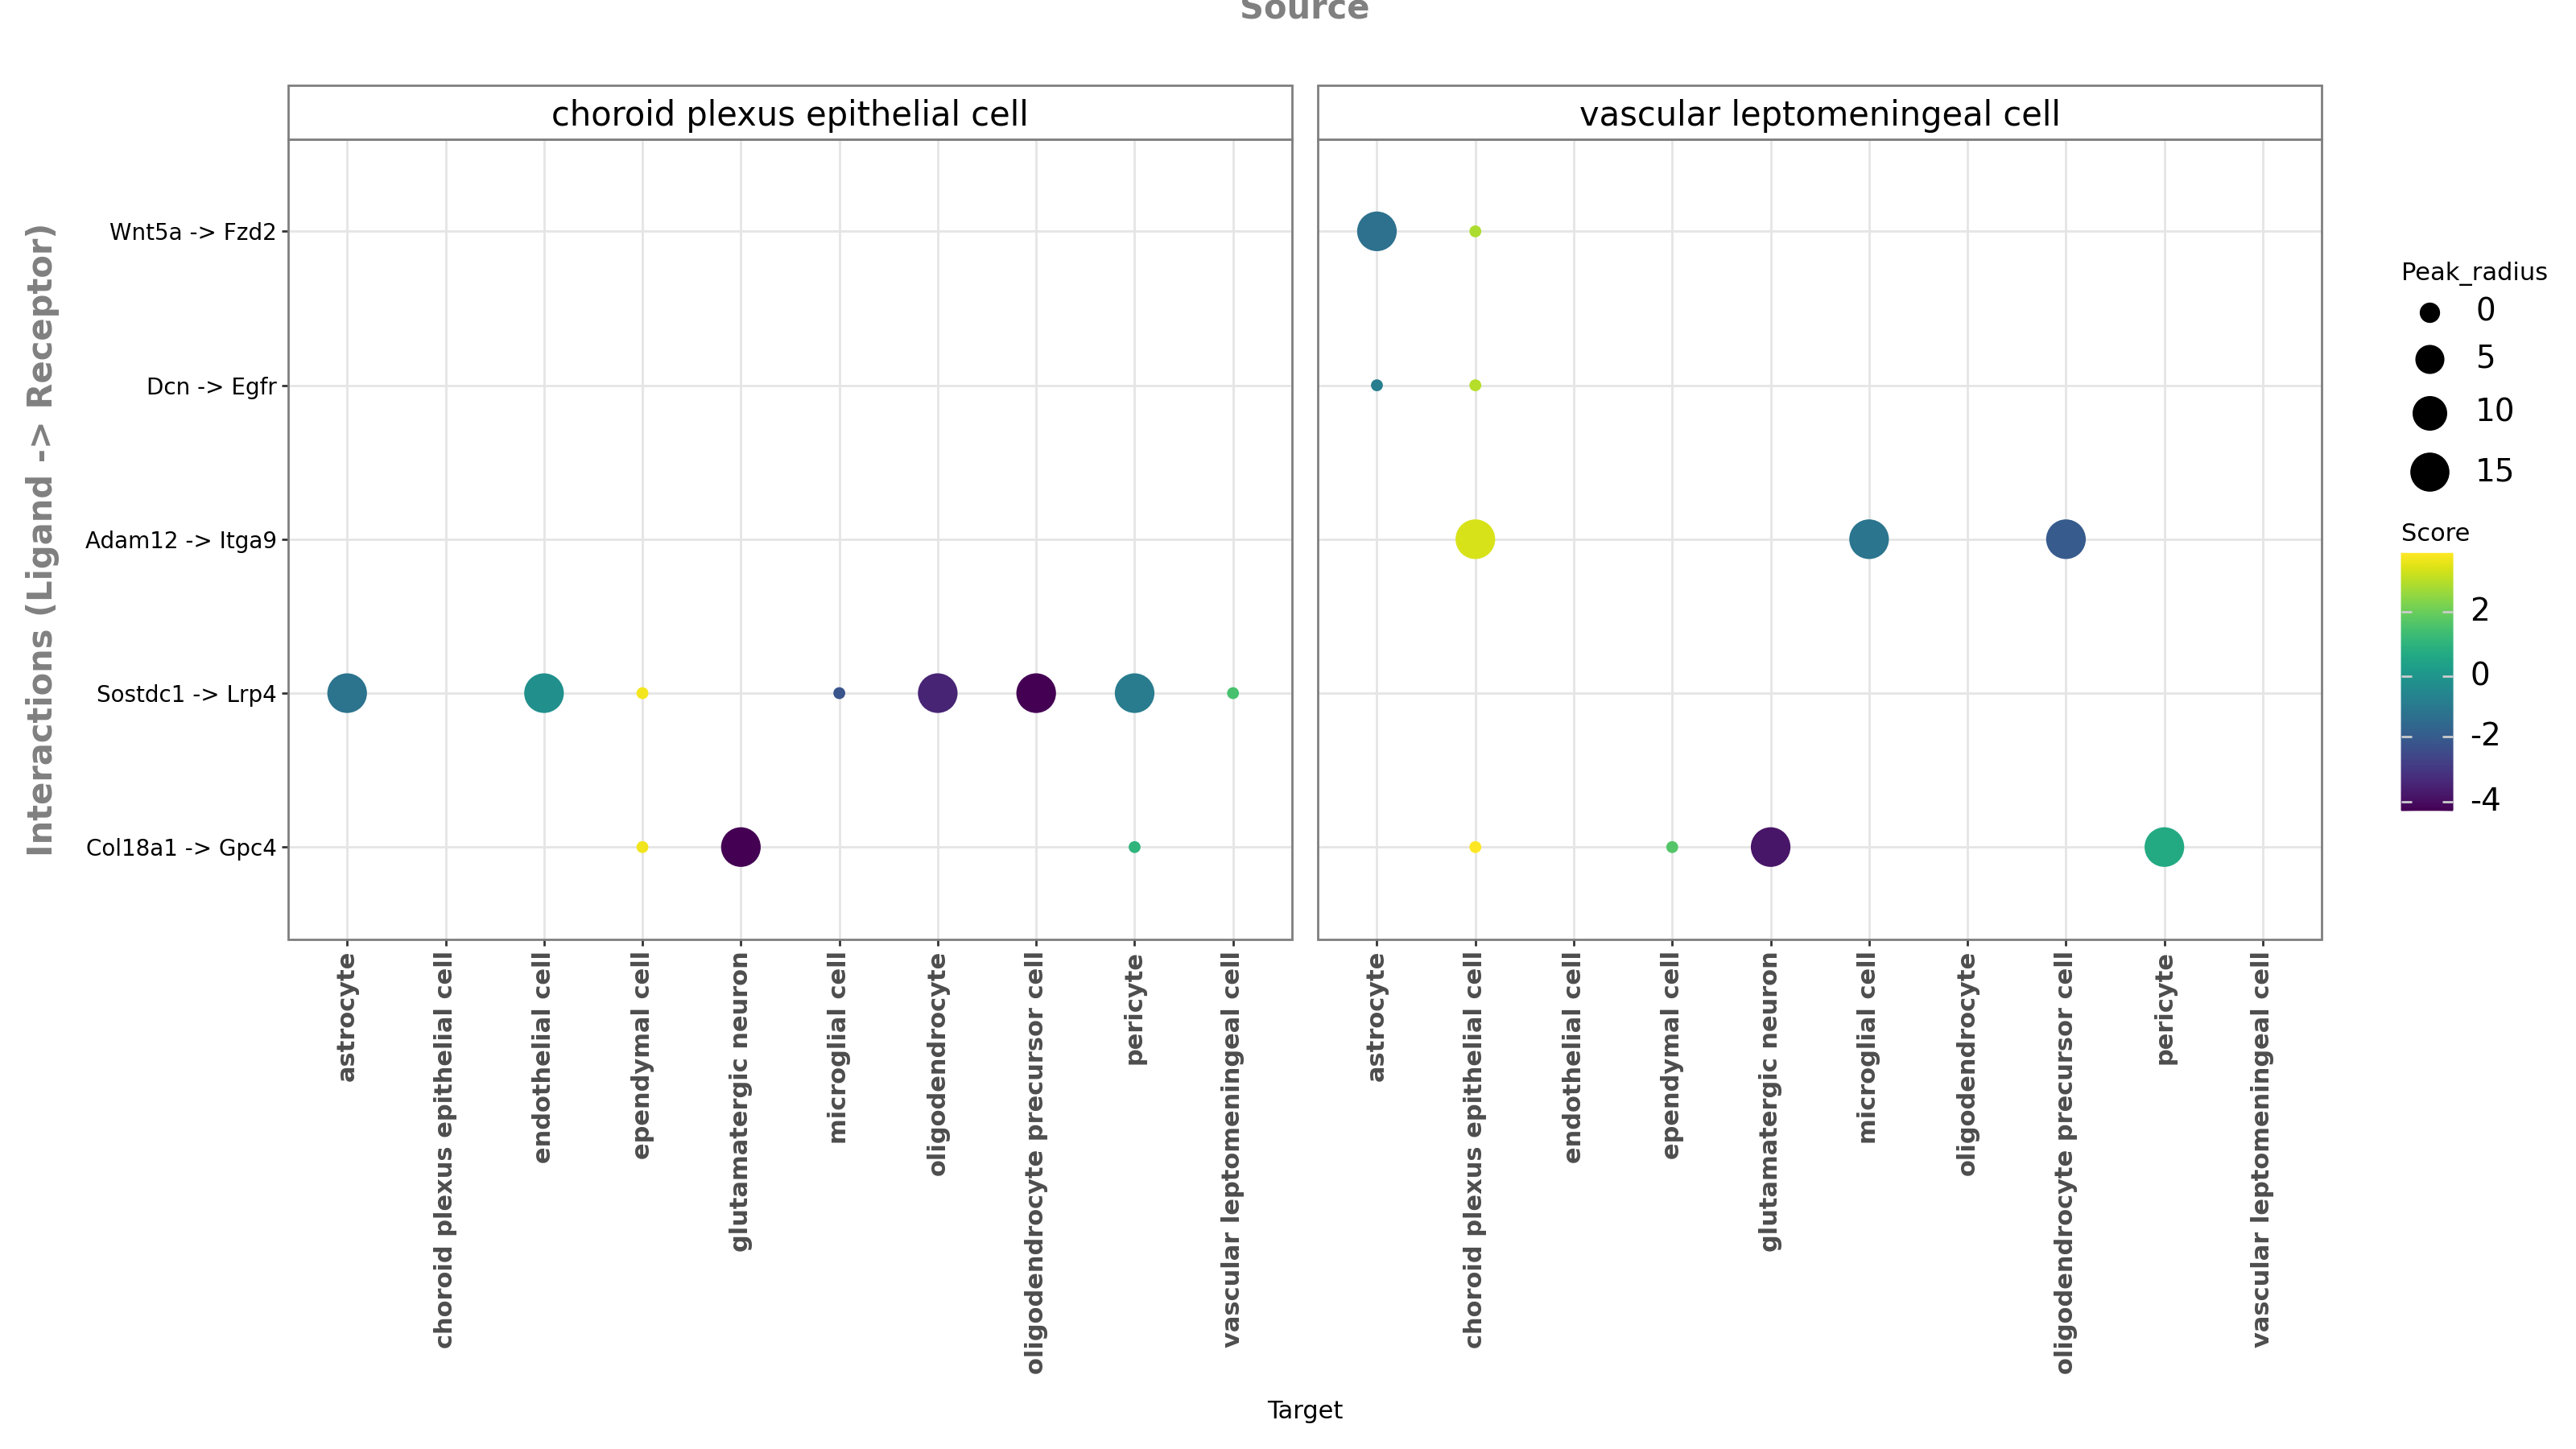

In [22]:
li.pl.dotplot(
    liana_res=lric_ct_res,
    colour="score", size="peak_radius", inverse_size=True,
    orderby="score",
    orderby_ascending=False, top_n=5,
    figure_size=(16, 9),
    source_labels=['vascular leptomeningeal cell', 'choroid plexus epithelial cell']
)


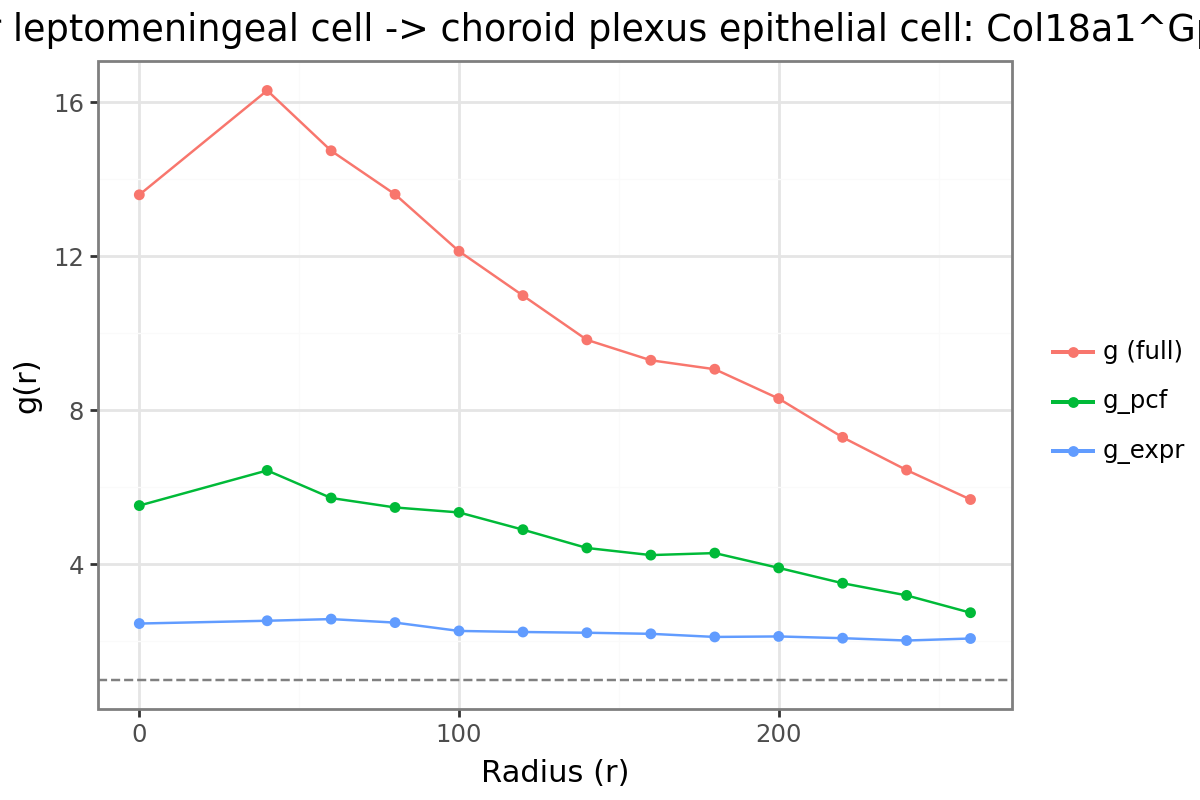

In [23]:
li.pl.lric_lineplot(adata, "lric_ct",
                    source="vascular leptomeningeal cell",
                    target="choroid plexus epithelial cell",
                    interaction="Col18a1^Gpc4")

**Col18a1 $\rightarrow$ Gpc4** from **vascular leptomeningeal cells $\rightarrow$ choroid plexus epithelial cells** shows the strongest cell-type-informed spatial enrichment, with $g_{\mathrm{full}}(r)$ peaking at approximately **16.3 around $40\,\mu\mathrm{m}$**.

The underlying cell-type organisation is already strongly enriched ($g_{\mathrm{pcf}} \approx 6.4$), reflecting the close spatial association of vascular leptomeningeal and choroid plexus epithelial cells. Ligand–receptor expression provides an additional enrichment component ($g_{\mathrm{expr}} \approx 2.5$), amplifying the full signal beyond that explained by cell-type proximity alone.

Thus, the interaction is supported by both anatomical co-localisation and non-random **Col18a1/Gpc4** expression within the respective sender and receiver populations.

---

## Comparing full interaction curves using divergence

Previously, we used AUC to collapse each interaction curve into a single number. This is simple and useful for ranking, but it discards where along radius r two curves differ. In addition, differences with opposite signs at different radii can cancel when summarized by a signed integral.
<br>
Here, we introduce a second summary score that compares the **full curves**: curve divergence.

Unlike `AUC–log2`, divergence does not describe whether an interaction is generally enriched or depleted. Instead, it answers:
> How different are these two spatial interaction profiles, and at what radius is their separation greatest?

`li.ut.get_lric_divergence` selects each curve as a `{column: value}` dict over *any* columns of the result. That makes it general: compare two interactions within one result, or — after concatenating results from several samples/conditions with e.g. a `condition` column — the **same interaction across conditions** by pinning that column. Rows a selection leaves unpinned (e.g. replicate samples) average into one curve.

**Read it as:** divergence `≈ 0` means the two spatial profiles are similar, while a larger value means they differ more strongly across distance; `r_star` is the radius where the separation peaks.

### CrossPCF

label_a         choroid plexus epithelial cell | ependymal cell
label_b       choroid plexus epithelial cell | oligodendrocy...
divergence                                             5.697153
r_star                                                      0.0
delta_star                                             7.958213
direction                                                 A > B
feature_a     {'source': 'choroid plexus epithelial cell', '...
feature_b     {'source': 'choroid plexus epithelial cell', '...
max_dist                                                   None


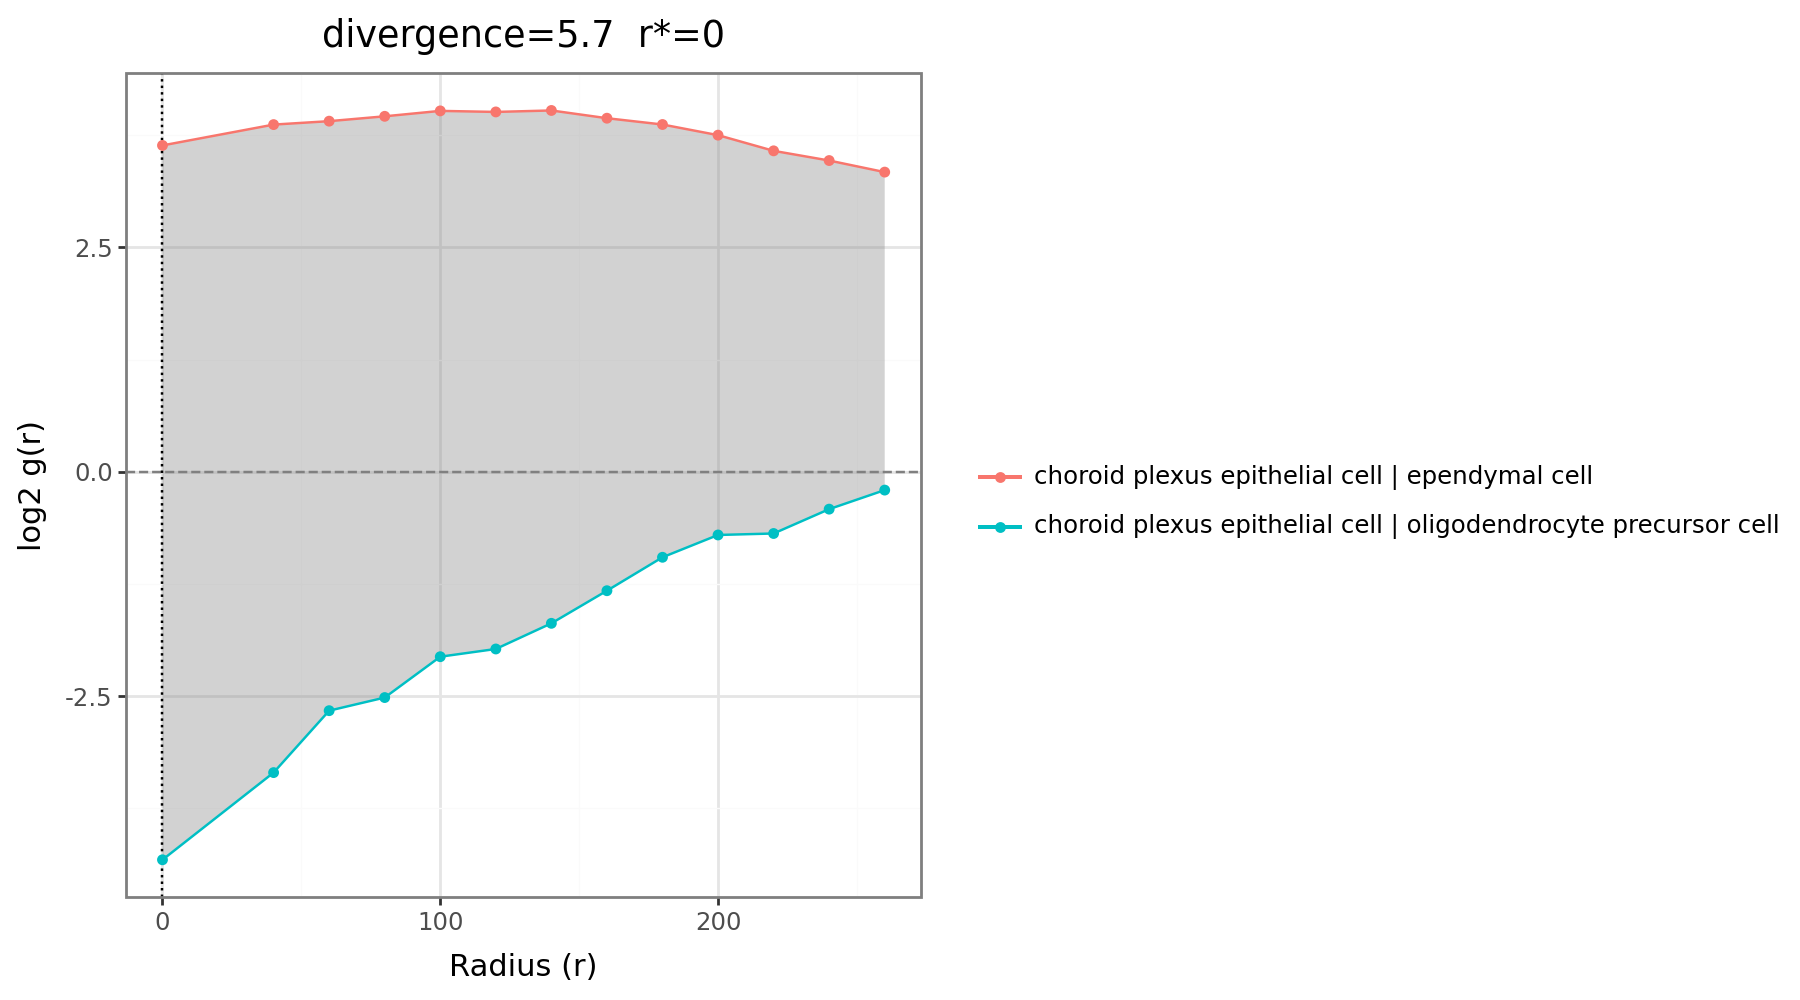

In [24]:
fa = dict(source="choroid plexus epithelial cell", target="ependymal cell")
fb = dict(source="choroid plexus epithelial cell", target="oligodendrocyte precursor cell")

div = li.ut.get_lric_divergence(adata, "cross_pcf", feature_a=fa, feature_b=fb)
print(div.to_string())

li.pl.lric_divergence_plot(adata, "cross_pcf", feature_a=fa, feature_b=fb, figure_size=(9, 5))


### agnostic LRIC

label_a                           Dcn^Egfr
label_b                          Dcn^Erbb4
divergence                        0.242382
r_star                                 0.0
delta_star                        0.904441
direction                            A > B
feature_a      {'interaction': 'Dcn^Egfr'}
feature_b     {'interaction': 'Dcn^Erbb4'}
max_dist                              None


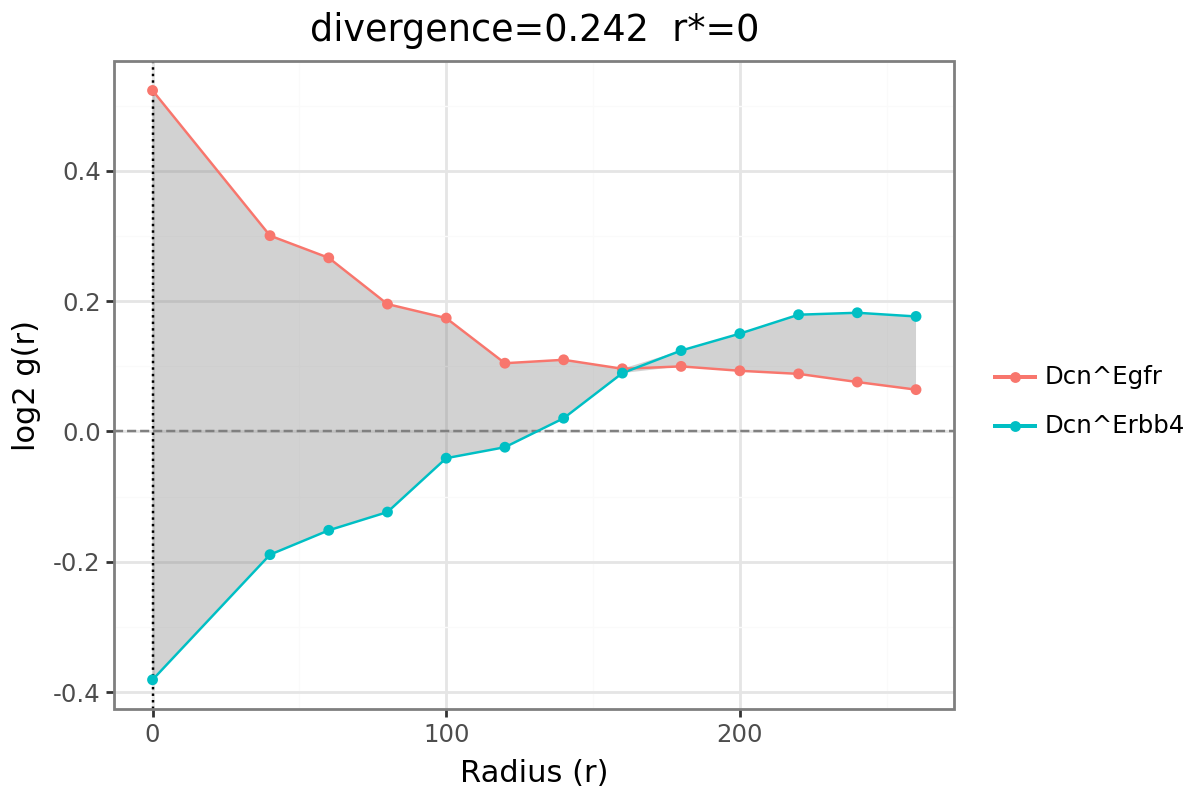

In [25]:
fa = dict(interaction="Dcn^Egfr")
fb = dict(interaction="Dcn^Erbb4")

div = li.ut.get_lric_divergence(adata, "lric_ag", feature_a=fa, feature_b=fb)
print(div.to_string())

li.pl.lric_divergence_plot(adata, "lric_ag", feature_a=fa, feature_b=fb)


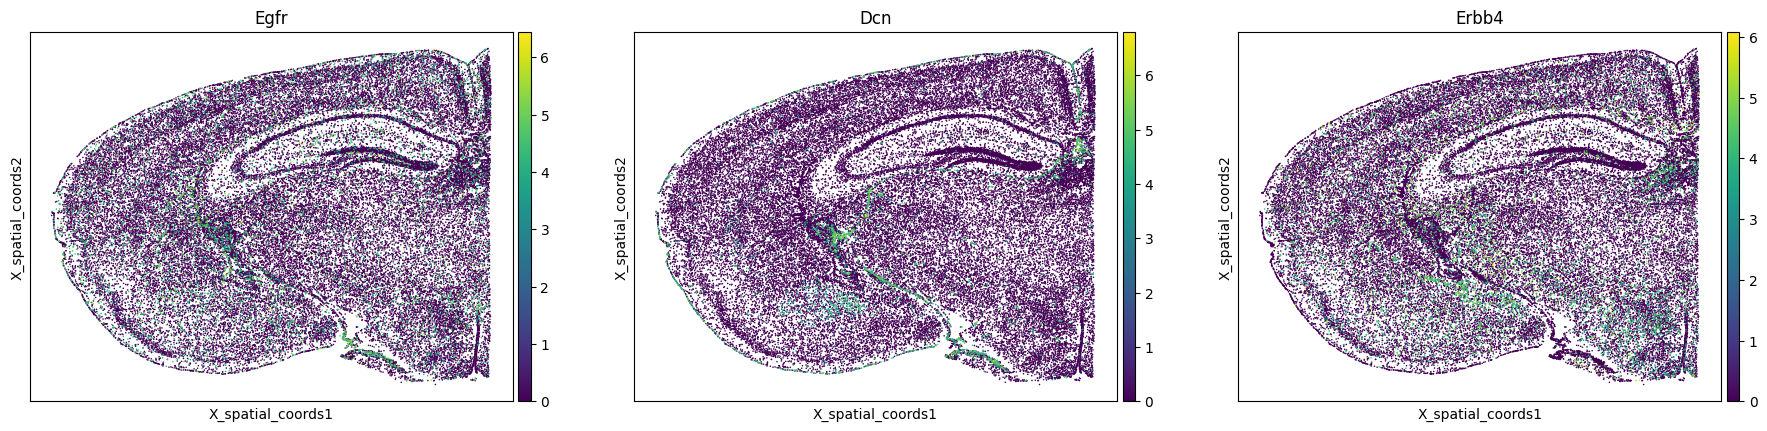

In [26]:
sc.pl.embedding(
    adata,
    basis=spatial_key,
    color=["Egfr", "Dcn", "Erbb4"],
    s=5,
    use_raw=False
)

### CT-informed LRIC

Here, we can see the same interaction being enriched in one cell type pair, and depleted in another.

label_a       vascular leptomeningeal cell | choroid plexus ...
label_b       vascular leptomeningeal cell | astrocyte | Wnt...
divergence                                             3.482253
r_star                                                      0.0
delta_star                                              4.28646
direction                                                 A > B
feature_a     {'source': 'vascular leptomeningeal cell', 'ta...
feature_b     {'source': 'vascular leptomeningeal cell', 'ta...
max_dist                                                   None


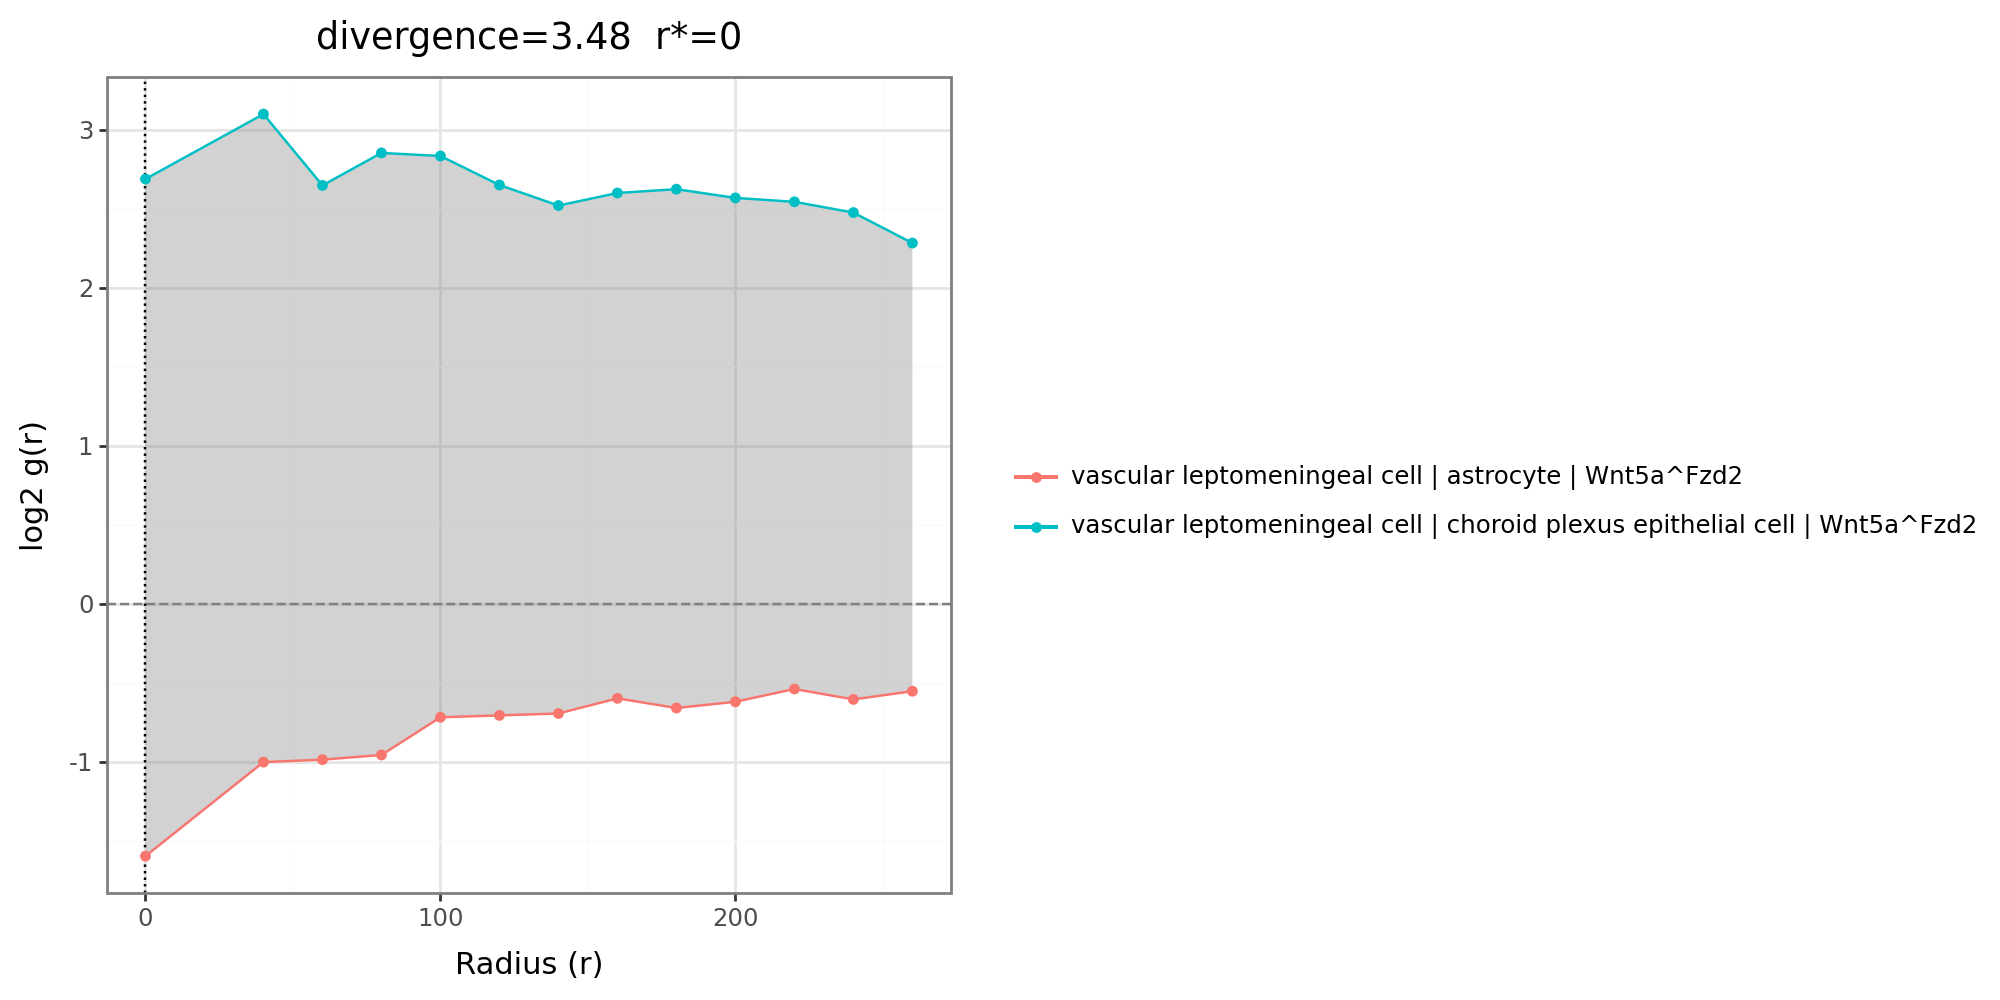

In [27]:
fa = dict(source="vascular leptomeningeal cell",
          target="choroid plexus epithelial cell", interaction="Wnt5a^Fzd2")
fb = dict(source="vascular leptomeningeal cell",
          target="astrocyte", interaction="Wnt5a^Fzd2")

div = li.ut.get_lric_divergence(adata, "lric_ct", feature_a=fa, feature_b=fb)
print(div.to_string())

li.pl.lric_divergence_plot(adata, "lric_ct", feature_a=fa, feature_b=fb, figure_size=(10, 5))


---

<div style="border:2px solid #790e0eff; background-color:#e3f2fd; padding:12px; border-radius:8px; font-size:1.1em; margin:10px 0;">
<strong>Note:</strong> This tutorial is part of an ongoing <b>LIANA+</b> extension (Alsayah et al., in prep). Feedback welcome!
</div>